# Phase 2 Validation: Feature Engineered Matrix Quality Assurance
**Author:** Bhavya Guleria  
**Objective:** To programmatically validate the integrity, dimensionality, and data types of the engineered feature matrix before it is passed to the machine learning models.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style for professional presentation
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


### Step 1: Load the Engineered Feature Matrix
Loading the dataset generated by `build_features.py` to verify the hardware-safe extraction was successful.

In [2]:
# Assuming this notebook is in the 'notebooks/' directory
file_path = '../data/processed/features_engineered.csv'

try:
    df = pd.read_csv(file_path)
    print("✅ Feature matrix loaded successfully!")
except FileNotFoundError:
    print("❌ Error: Could not find the file. Please ensure 'build_features.py' has been run.")

✅ Feature matrix loaded successfully!


### Step 2: Dimensionality & Cohort Integrity Check
Validating that no patient records were lost during the complex dataframe merges and chunked processing.

In [3]:
print("=" * 50)
print("DIMENSIONALITY CHECK")
print("=" * 50)

expected_rows = 73181

print(f"Total ICU Stays (Rows): {df.shape[0]:,}")
print(f"Total Features & Targets (Columns): {df.shape[1]}")

if df.shape[0] == expected_rows:
    print(f"✅ PASSED: Row count perfectly matches the Phase 1 cohort extraction ({expected_rows:,} stays).")
else:
    print(f"⚠️ WARNING: Expected {expected_rows} rows, but found {df.shape[0]}.")
    
# Calculate the exact number of input features (subtracting IDs and targets)
id_and_target_cols = [
    'subject_id', 'hadm_id', 'stay_id', 'mortality', 'los_days', 'los_category',
    'icu_readmit_48h', 'icu_readmit_7d', 'discharge_disposition',
    'need_vent_any', 'need_vasopressor_any', 'need_rrt_any',
    'aki_onset', 'ards_onset', 'liver_injury_onset', 'sepsis_onset'
]

actual_targets_in_df = [col for col in id_and_target_cols if col in df.columns]
input_features_count = df.shape[1] - len(actual_targets_in_df)

print(f"✅ PASSED: Successfully isolated {input_features_count} engineered input features.")

DIMENSIONALITY CHECK
Total ICU Stays (Rows): 73,181
Total Features & Targets (Columns): 128
✅ PASSED: Row count perfectly matches the Phase 1 cohort extraction (73,181 stays).
✅ PASSED: Successfully isolated 112 engineered input features.


### Step 3: Missing Value (NaN) Inspection
Machine learning models like XGBoost can handle missing values, but a high percentage indicates an extraction failure. We must ensure our feature matrix is dense.

In [4]:
print("=" * 50)
print("MISSING VALUES CHECK")
print("=" * 50)

total_cells = df.shape[0] * df.shape[1]
missing_cells = df.isnull().sum().sum()
missing_percentage = (missing_cells / total_cells) * 100

print(f"Total missing values across entire matrix: {missing_cells:,}")
print(f"Matrix Sparsity / Missing Rate: {missing_percentage:.4f}%")

if missing_percentage < 1.0:
    print("✅ PASSED: The dataset is highly complete. No severe extraction failures detected.")
else:
    print("⚠️ WARNING: High number of missing values detected. Review imputation strategy.")

MISSING VALUES CHECK
Total missing values across entire matrix: 0
Matrix Sparsity / Missing Rate: 0.0000%
✅ PASSED: The dataset is highly complete. No severe extraction failures detected.


### Step 4: Binary Encoding Validation (Diagnoses & Procedures)
We replaced continuous biological data with top-N clinical proxies. We must mathematically verify these are strictly formatted as `0` or `1`.

In [5]:
print("=" * 50)
print("BINARY ENCODING CHECK")
print("=" * 50)

# Isolate columns generated for diagnoses and procedures
diag_proc_cols = [col for col in df.columns if col.startswith('diag_') or col.startswith('proc_')]

print(f"Validating {len(diag_proc_cols)} engineered clinical proxy features...")

# Check if every value in these columns is strictly 0 or 1
is_strictly_binary = df[diag_proc_cols].isin([0, 1]).all().all()

if is_strictly_binary:
    print("✅ PASSED: All top-N diagnosis and procedure features are correctly encoded as binary (1/0).")
else:
    print("❌ FAILED: Non-binary values detected in proxy columns. Pipeline review required.")

BINARY ENCODING CHECK
Validating 80 engineered clinical proxy features...
✅ PASSED: All top-N diagnosis and procedure features are correctly encoded as binary (1/0).


### Step 5: Target Distribution & Class Imbalance Verification
Verifying the mortality rate matches the initial cohort statistics to ensure the labels were merged correctly with the new features.

✅ PASSED: Baseline Mortality Rate confirmed at 11.38%


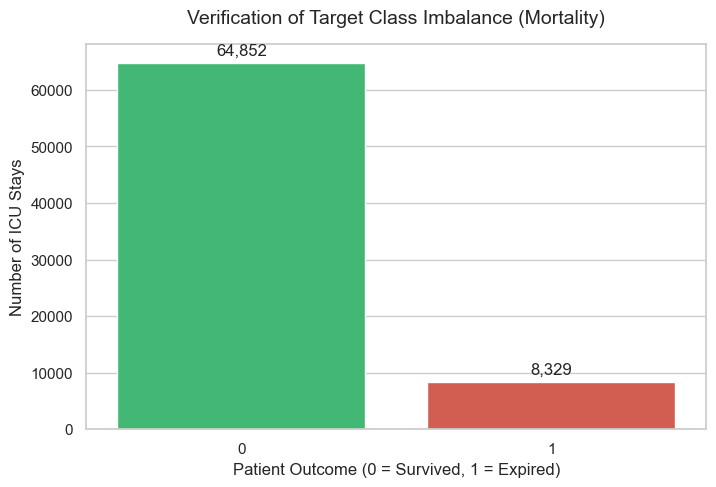

In [6]:
# Visualize the Mortality Class Imbalance
if 'mortality' in df.columns:
    mortality_counts = df['mortality'].value_counts()
    mortality_rate = (mortality_counts[1] / df.shape[0]) * 100
    
    print(f"✅ PASSED: Baseline Mortality Rate confirmed at {mortality_rate:.2f}%")
    
    # Plotting
    plt.figure(figsize=(8, 5))
    ax = sns.countplot(data=df, x='mortality', palette=['#2ecc71', '#e74c3c'])
    plt.title('Verification of Target Class Imbalance (Mortality)', fontsize=14, pad=15)
    plt.xlabel('Patient Outcome (0 = Survived, 1 = Expired)', fontsize=12)
    plt.ylabel('Number of ICU Stays', fontsize=12)
    
    # Add count labels on top of bars
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points')
    
    plt.show()
else:
    print("Target column 'mortality' not found in dataset.")